# Universidad de Buenos Aires
## Laboratorio de Sistemas Embebidos
### Especialización en Inteligencia Artificial
#### Análisis de Series de Tiempo 1
**Docente**: Camilo Argoty

**Alumnos**:

- Gaspar Acevedo Zain (código a2101).
- Rodrigo Lauro (código a2120).

**Códigos**:

- a2101
- a2120

**Fecha**: 18/06/2026

---

# Trabajo Práctico Final — Notebook 2

## Baselines y estacionaridad — Volumen de tráfico I-94

**Dataset:** Metro Interstate Traffic Volume (UCI)  
**Variable objetivo:** `traffic_volume` (vehículos/hora)  
**Subperiodo:** 2016-01-01 a 2017-12-31  
**Estacionalidad principal:** s = 24 (ciclo diario)  
**Entrada:** artefactos del Notebook 1 en `dataset/processed/`

## 2.1 - Setup y carga

En esta sección se importan las librerías necesarias, se configuran rutas y parámetros globales, y se carga la serie horaria de tráfico ya procesada en la Notebook 1.

In [65]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

In [66]:
RANDOM_SEED = 381047
np.random.seed(RANDOM_SEED)

BASE_DIR = Path(".").resolve()
PROCESSED_DIR = BASE_DIR / "dataset" / "processed"
RESULTS_DIR = BASE_DIR / "dataset" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAFFIC_PATH = PROCESSED_DIR / "traffic_horario.csv"
SEASONAL_PERIOD = 24
TEST_HOURS = 672

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("colorblind")
plt.rcParams.update({"figure.figsize": (12, 4), "font.size": 11})

El archivo `traffic_horario.csv` contiene dos columnas:

- `date_time`: marca temporal horaria.
- `traffic_volume`: volumen de vehículos por hora (entero, sin valores faltantes en NB1).

La unidad de análisis es vehículos/hora en la autopista I-94 oeste (Minneapolis–St Paul), subperiodo 2016–2017.

In [67]:
df_traffic = pd.read_csv(TRAFFIC_PATH, parse_dates=["date_time"])
y = (
    df_traffic.set_index("date_time")["traffic_volume"]
    .sort_index()
    .astype(float)
)

print(f"Observaciones cargadas: {len(y)}")
print(f"Desde: {y.index.min()}  Hasta: {y.index.max()}")

Observaciones cargadas: 16551
Desde: 2016-01-01 00:00:00  Hasta: 2017-12-31 23:00:00


## 2.2 - Partición train / test

En esta sección se divide la serie en conjunto de entrenamiento y conjunto de prueba.

Se opta por tomar las últimas $4$ semanas ($672$ horas) como datos de *test*. De esta manera, el dataset de $train$ se conformará de $15879$ registros.

El dataset de *train* se utilizará para ajustar los distintos modelos que se estudiarán, mientras que *test* simulará información futura no vista.

In [68]:
y_test = y.iloc[-TEST_HOURS:]
y_train = y.iloc[:-TEST_HOURS]
cutoff = y_train.index[-1]

split_info = {
    "cutoff_train_end": cutoff.isoformat(),
    "test_start": y_test.index[0].isoformat(),
    "test_end": y_test.index[-1].isoformat(),
    "n_train": int(len(y_train)),
    "n_test": int(len(y_test)),
}

split_path = PROCESSED_DIR / "train_test_split.json"
with open(split_path, "w", encoding="utf-8") as f:
    json.dump(split_info, f, indent=2)

print(f"Train: {len(y_train)} obs. (hasta {cutoff})")
print(f"Test:  {len(y_test)} obs.")
print(f"Guardado: {split_path}")

Train: 15879 obs. (hasta 2017-12-03 19:00:00)
Test:  672 obs.
Guardado: C:\fiuba\CEIA-AST\TPs\TP-02\dataset\processed\train_test_split.json


## 2.3 - Descomposición ETS

En esta sección se descompone la serie de entrenamiento en tendencia ($T_t$), estacionalidad ($S_t$) y residuo ($R_t$) con `seasonal_decompose` y período $s = 24$.

Antes de ajustar modelos paramétricos conviene visualizar la estructura de la serie. El tráfico horario exhibe un ciclo diario marcado (hora pico vs. valle nocturno). Comparar descomposición **aditiva** y **multiplicativa** orienta la elección de baselines en las secciones posteriores. Si la amplitud del ciclo crece con el nivel de tráfico, la forma multiplicativa puede ser más adecuada.

Se aplicará `seasonal_decompose` sobre `y_train` con `period=24` en ambos modos y se graficarán los cuatro componentes.

A continuación se muestra la descomposición **aditiva**. En el subplot de estacionalidad se busca el patrón de hora pico repetido cada $24$ observaciones; en residuo, la ausencia de estructura sistemática evidente.

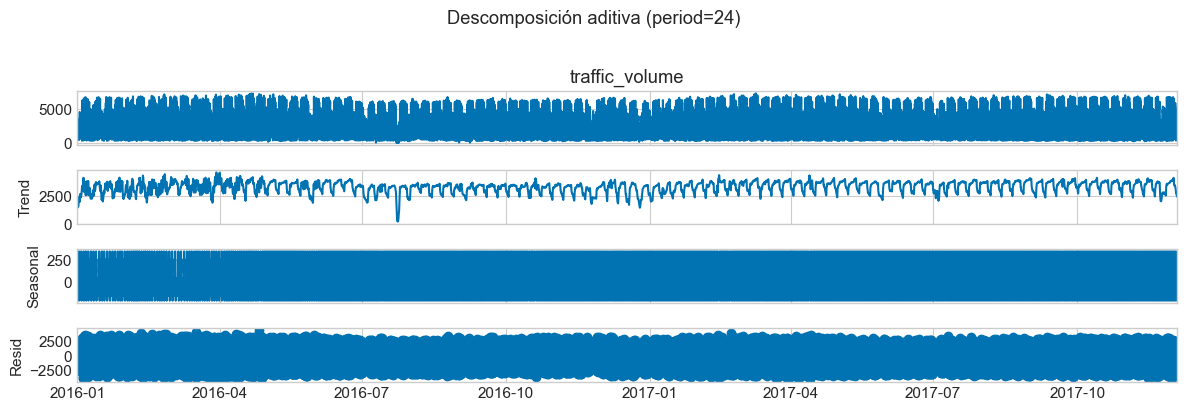

In [69]:
decomp_add = seasonal_decompose(
    y_train,
    model="additive",
    period=SEASONAL_PERIOD,
    extrapolate_trend="freq",
)
decomp_add.plot()
plt.suptitle("Descomposición aditiva (period=24)", y=1.02)
plt.tight_layout()
plt.show()

A continuación se muestra la descomposición **multiplicativa** de la misma serie.

La forma multiplicativa exige valores estrictamente positivos: en train hay $2$ observaciones con `traffic_volume = 0`. Para esta visualización se aplica un **desplazamiento** $y'_t = y_t + 1$ veh/h. La forma del ciclo estacional es comparable, pero los niveles de los componentes no están en las unidades originales.

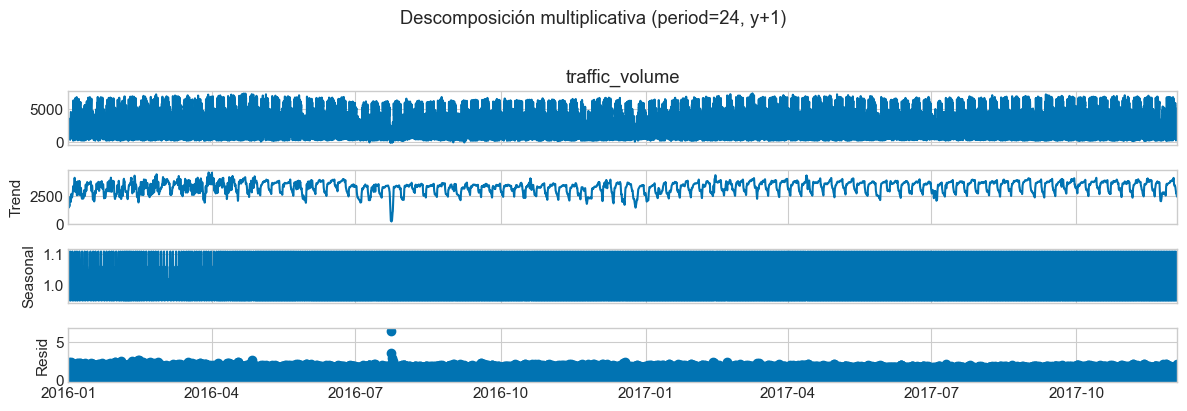

In [70]:
# Desplazamiento +1: multiplicativa no admite ceros (2 obs. con y=0 en train)
y_train_pos = y_train + 1

decomp_mul = seasonal_decompose(
    y_train_pos,
    model="multiplicative",
    period=SEASONAL_PERIOD,
    extrapolate_trend="freq",
)
decomp_mul.plot()
plt.suptitle("Descomposición multiplicativa (period=24, y+1)", y=1.02)
plt.tight_layout()
plt.show()

### Conclusiones

- Ambas descomposiciones confirman una **estacionalidad diaria fuerte** (`period=24`): el tráfico oscila de forma regular entre horas valle (~500–800 veh/h) y pico (~4.000–5.000 veh/h).
- En la descomposición **aditiva**, la componente estacional (±250 veh/h) es pequeña frente al **residuo** (±3.500 veh/h): con `period=24` no se captura la estacionalidad semanal (laboral vs. fin de semana), que queda en tendencia y residuo.
- La descomposición **multiplicativa** (`y+1`) separa mejor tendencia y ciclo: la estacionalidad oscila en torno a 1 (±5–10 %), más coherente con tráfico urbano donde la amplitud del ciclo crece con el nivel.
- **Qué implica?** $s=24$ es la estacionalidad principal para modelado. La superioridad visual de la descomposición multiplicativa motiva a probar ETS(M,Ad,M) en secciones posteriores.

## 2.4 - Holt-Winters (suavizado exponencial triple)

En esta sección se ajusta un modelo **Holt-Winters** con suavizado exponencial triple (**ETS(A,A,A)**). Se utiliza una tendencia aditiva *sin amortiguación* y estacionalidad aditiva con `seasonal_periods = 24`.

La idea es utilizar Holt-Winters como baseline, el cuál será comparado posteriormente con otros modelos, tales como SARIMA, SARIMAX y Prophet.

Este modelo se ajustará sobre `y_train` con `trend="add"`, `seasonal="add"` (sin `damped_trend`) y se constratará con una variante amortiguada **ETS(A,Ad,A)** para comparar in-sample y out-of-sample en igualdad de condiciones.

**NOTA:** el ajuste puede demorar algunos minutos sobre $15879$ registros.

In [ ]:
hw_model = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal="add",
    seasonal_periods=SEASONAL_PERIOD,
    initialization_method="estimated",
).fit(optimized=True)

print(hw_model.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:           traffic_volume   No. Observations:                15879
Model:             ExponentialSmoothing   SSE                    13852923357.629
Optimized:                         True   AIC                         217264.990
Trend:                         Additive   BIC                         217479.827
Seasonal:                      Additive   AICC                        217265.107
Seasonal Periods:                    24   Date:                 Sun, 14 Jun 2026
Box-Cox:                          False   Time:                         01:59:57
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.9596429                alpha                 True
smoothing_trend          

### Conclusiones

- El Holt-Winters **ETS(A,A,A)** converge con AIC ≈ 217.265 sobre 15.879 observaciones de train.
- Parámetros de suavizado: **$\alpha \approx 0{,}96$** (nivel muy reactivo), **$\beta \approx 0{,}0001$** (tendencia casi fija in-sample), **$\gamma \approx 0{,}024$** (estacionalidad lenta de adaptar).
- El alto $\alpha$ indica que el nivel sigue de cerca las observaciones recientes; el bajo $\gamma$ sugiere estacionalidad **rígida** que puede desalinearse al extrapolar 672 pasos.

## 2.5 - Modelos ETS

En esta sección se estiman modelos **ETS** mediante `ETSModel`, se ajusta Holt-Winters **amortiguado** y se comparan todos los baselines con el **AIC** (Akaike Information Criterion).

La familia ETS generaliza Holt-Winters permitiendo distintas combinaciones de error, tendencia y estacionalidad. Es importante notar que `ETSModel(..., trend="add")` implementa tendencia aditiva **amortiguada** — **ETS(A,Ad,A)** — mientras que el Holt-Winters de la sección anterior es es **ETS(A,A,A)** (sin amortiguación).

Un AIC menor indica mejor compromiso entre ajuste y parsimonia **in-sample**, pero no garantiza mejor pronóstico en test.

Este es el procedimiento que se realizará a continuación:

1. Ajustar **ETS(A,Ad,A)** sobre `y_train`.
2. Ajustar **Holt-Winters amortiguado** (`damped_trend=True`) como contraparte directa de ETS(A,Ad,A).
3. Intentar **ETS(M,Ad,M)** sobre `y_train + 1`.
4. Construir tabla comparativa de AIC.

In [72]:
ets_add = ETSModel(
    y_train,
    error="add",
    trend="add",
    seasonal="add",
    seasonal_periods=SEASONAL_PERIOD,
).fit()

# Contraparte amortiguada de ETS(A,Ad,A) dentro de ExponentialSmoothing
hw_damped_model = ExponentialSmoothing(
    y_train,
    trend="add",
    damped_trend=True,
    seasonal="add",
    seasonal_periods=SEASONAL_PERIOD,
    initialization_method="estimated",
).fit(optimized=True)

ets_mul = None
ets_mul_error = None
try:
    ets_mul = ETSModel(
        y_train_pos,
        error="mul",
        trend="add",
        seasonal="mul",
        seasonal_periods=SEASONAL_PERIOD,
    ).fit()
except Exception as exc:
    ets_mul_error = str(exc)
    print(f"ETS(M,Ad,M) sobre y+1 no convergió o falló: {exc}")

rows_aic = [
    {"modelo": "Holt-Winters (A,A,A)", "AIC": hw_model.aic},
    {"modelo": "Holt-Winters amortiguado (A,Ad,A)", "AIC": hw_damped_model.aic},
    {"modelo": "ETS(A,Ad,A)", "AIC": ets_add.aic},
]
if ets_mul is not None:
    rows_aic.append({"modelo": "ETS(M,Ad,M) y+1", "AIC": ets_mul.aic})

aic_compare = pd.DataFrame(rows_aic).sort_values("AIC")
print(aic_compare.to_string(index=False))
print(f"\nMejor baseline por AIC (in-sample): {aic_compare.iloc[0]['modelo']}")
print(
    "Nota: el AIC compara ajuste in-sample; el desempeño en test se evalúa en §2.6."
)

                           modelo           AIC
Holt-Winters amortiguado (A,Ad,A) 217192.128650
             Holt-Winters (A,A,A) 217264.989620
                      ETS(A,Ad,A) 262413.404522
                  ETS(M,Ad,M) y+1 293248.460157

Mejor baseline por AIC (in-sample): Holt-Winters amortiguado (A,Ad,A)
Nota: el AIC compara ajuste in-sample; el desempeño en test se evalúa en §2.6.


### Conclusiones

- **Mejor AIC in-sample:** Holt-Winters amortiguado (A,Ad,A) con AIC ≈ 217.192, seguido de HW clásico (≈ 217.265) y ETS(A,Ad,A) (≈ 262.413).
- El **AIC favorece ajuste in-sample**; no garantiza mejor pronóstico a 4 semanas. Para seleccionar un baseline se debe realizar una la validación out-of-sample.

## 2.6 - Pronóstico de baselines en test

En esta sección se generan pronósticos de $672$ pasos para Holt-Winters (clásico y amortiguado) y los modelos ETS ajustados, y se calculan métricas de error.

Estas métricas definen el umbral mínimo que modelos tales como SARIMA y SARIMAX deben superar.

**Métricas:**
- **MAE** (error absoluto medio): interpretable en vehículos/hora; promedio de desvíos sin signo.
- **RMSE** (raíz del error cuadrático medio): penaliza errores grandes; sensible a picos mal predichos (hora pico).
- **MAPE** (error porcentual absoluto medio): escala relativa en %; útil para comparar magnitudes, pero inestable si $y_t \approx 0$ (horas de madrugada).

**Resultado esperado:** tabla ordenada por RMSE con todos los baselines disponibles. Se espera que el mejor AIC in-sample no coincida necesariamente con el mejor RMSE out-of-sample.

In [73]:
def eval_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_true - y_pred
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))
    mape = np.nanmean(np.abs(err / np.where(y_true == 0, np.nan, y_true))) * 100
    return mae, rmse, mape


def forecast_aligned(model, steps, index):
    """Pronóstico alineado al índice de test (evita NaN por desajuste de índices)."""
    return pd.Series(model.forecast(steps).values, index=index)


hw_fc = forecast_aligned(hw_model, len(y_test), y_test.index)
hw_damped_fc = forecast_aligned(hw_damped_model, len(y_test), y_test.index)
ets_add_fc = forecast_aligned(ets_add, len(y_test), y_test.index)

forecast_specs = [
    ("Holt-Winters (A,A,A)", hw_fc),
    ("Holt-Winters amortiguado (A,Ad,A)", hw_damped_fc),
    ("ETS(A,Ad,A)", ets_add_fc),
]
if ets_mul is not None:
    ets_mul_fc = forecast_aligned(ets_mul, len(y_test), y_test.index) - 1
    forecast_specs.append(("ETS(M,Ad,M) y+1", ets_mul_fc))

rows_metrics = []
for name, pred in forecast_specs:
    mae, rmse, mape = eval_metrics(y_test.values, pred.values)
    rows_metrics.append({"modelo": name, "MAE": mae, "RMSE": rmse, "MAPE": mape})

metrics_baselines = pd.DataFrame(rows_metrics).sort_values("RMSE")
print(metrics_baselines.round(3).to_string(index=False))
best_oos = metrics_baselines.iloc[0]
print(
    f"\nMejor baseline por RMSE (out-of-sample): {best_oos['modelo']} "
    f"(MAE={best_oos['MAE']:.1f}, RMSE={best_oos['RMSE']:.1f})"
)

                           modelo       MAE      RMSE     MAPE
Holt-Winters amortiguado (A,Ad,A)  1512.659  1803.728  169.973
                      ETS(A,Ad,A)  1612.574  1848.225  157.550
             Holt-Winters (A,A,A)  8592.768  9896.236  731.768
                  ETS(M,Ad,M) y+1 25081.736 29093.578 1992.911

Mejor baseline por RMSE (out-of-sample): Holt-Winters amortiguado (A,Ad,A) (MAE=1512.7, RMSE=1803.7)


En función del **RMSE** los mejores pronósticos corresponden a **Holt-Winters amortiguado (A,Ad,A)** y **ETS(A,Ad,A)** (para las dos primeras semanas de *test*).

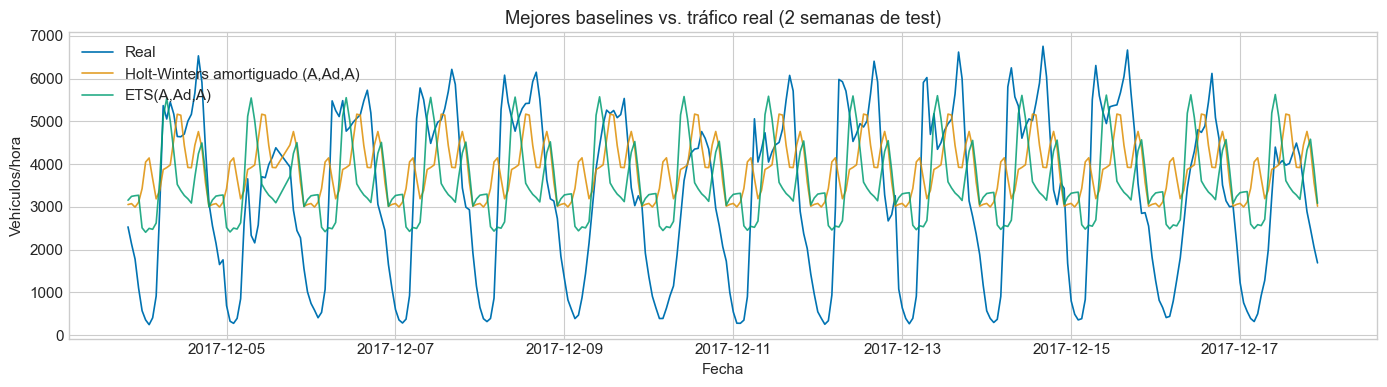

In [74]:
plot_h = min(336, len(y_test))  # 2 semanas
idx = y_test.index[:plot_h]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(idx, y_test.iloc[:plot_h], label="Real", linewidth=1.2)
ax.plot(
    idx,
    hw_damped_fc.iloc[:plot_h],
    label="Holt-Winters amortiguado (A,Ad,A)",
    linewidth=1.2,
    alpha=0.85,
)
ax.plot(
    idx,
    ets_add_fc.iloc[:plot_h],
    label="ETS(A,Ad,A)",
    linewidth=1.2,
    alpha=0.85,
)
ax.set_title("Mejores baselines vs. tráfico real (2 semanas de test)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Vehículos/hora")
ax.legend()
plt.tight_layout()
plt.show()

### Conclusiones

- Mejor baseline out-of-sample:
   - **Holt-Winters amortiguado (A,Ad,A)**, con *MAE = 1.513* y *RMSE = 1.804 veh/h*. 
   - **ETS(A,Ad,A)**, con *MAE = 1.613* y *RMSE = 1.848*.
- Respecto a **Holt-Winters clásico (A,A,A)**:
  - Tiene un peor desempeño en test, con *MAE = 8.593* y *RMSE = 9.896*, a pesar de que tiene un AIC competitivo in-sample (≈ 217.265).
  - Es decir, la tendencia no amortiguada extrapola mal a $672$ h.
- Respecto a las métricas:
  - **MAPE** (150–730 % en modelos aditivos) es poco confiable por horas de madrugada con tráfico bajo.
  - **MAE y RMSE** serán las métricas de referencia.
- El gráfico de dos semanas muestra que Holt-Winters amortiguado y ETS(A,Ad,A) reproducen el ciclo diario con error moderado (~49 % del tráfico medio).

## 2.7 - Test de estacionaridad (ADF)

En esta sección se aplica el test **Augmented Dickey-Fuller (ADF)** a cuatro transformaciones de la serie de entrenamiento:

1. **Niveles** originales.
2. **Logaritmo** — se usa `log1p(y) = log(1+y)` porque hay $2$ observaciones con tráfico $=0$ en train; `log(0)` no está definido.
3. **Primera diferencia** $\Delta y_t$ (candidato $d=1$).
4. **Diferencia estacional** $\Delta_{24} y_t$ (candidato $D=1$).

**Motivación:** los modelos SARIMA requieren estacionariedad en media (y preferentemente en varianza). El ADF evalúa la hipótesis nula $H_0$: existencia de raíz unitaria (serie no estacionaria). Si $p < 0{,}05$, se rechaza $H_0$ y hay evidencia de estacionariedad.

**Resultado esperado:** niveles y log1p probablemente no estacionarios; tras diferenciar, rechazo de $H_0$.

In [75]:
def clean_series(series):
    """Elimina NaN/Inf antes del ADF."""
    return pd.Series(series, dtype=float).replace([np.inf, -np.inf], np.nan).dropna()


adf_specs = [
    ("Niveles", y_train),
    ("Log1p", np.log1p(y_train)),
    ("Diff(1)", y_train.diff().dropna()),
    ("Diff estacional (24)", y_train.diff(SEASONAL_PERIOD).dropna()),
]

ADF_MAXLAG = 48  # acota autolag AIC para estabilidad numérica

adf_rows = []
for label, series in adf_specs:
    s = clean_series(series)
    stat, pval, usedlag, nobs, crit, icbest = adfuller(
        s, autolag="AIC", maxlag=ADF_MAXLAG
    )
    adf_rows.append(
        {
            "transformacion": label,
            "estadistico": stat,
            "p_valor": pval,
            "n_obs": nobs,
            "lag_usado": usedlag,
        }
    )

adf_results = pd.DataFrame(adf_rows)
print(adf_results.round(4).to_string(index=False))

      transformacion  estadistico  p_valor  n_obs  lag_usado
             Niveles     -16.3895      0.0  15830         48
               Log1p     -16.7125      0.0  15830         48
             Diff(1)     -24.2246      0.0  15829         48
Diff estacional (24)     -19.5501      0.0  15806         48


**Interpretación fila por fila (ADF):**

| Transformación | Lectura |
|----------------|---------|
| **Niveles** | $p \approx 0$: con $n = 15879$ el test tiene poder muy alto y rechaza $H_0$ (raíz unitaria). **No implica** que la serie sea ruido blanco: la estacionalidad diaria y los huecos horarios persisten. |
| **Log1p** | Mismo resultado; `log1p` estabiliza varianza sin eliminar la estructura temporal. |
| **Diff(1)** | Rechazo de $H_0$ → se propone **$d = 1$** para SARIMA. |
| **Diff estacional (24)** | Rechazo de $H_0$ → respalda evaluar **$D = 1$** con $s = 24$. |

### Conclusiones

- En las **cuatro transformaciones** probadas, el ADF rechaza $H_0$ ($p \approx 0$ o $p < 0{,}001$), incluidos **niveles** (estadístico ≈ −16,39) y **log1p** (≈ −16,71).
- Con $n = 15879$, el test tiene **poder muy alto**. Un $p \approx 0$ en niveles **no implica** ruido blanco ni ausencia de estacionalidad, solo indica rechazo de raíz unitaria bajo la hipótesis del ADF.
- **Diff(1)** (estadístico ≈ −24,22) respalda **$d = 1$**; **Diff estacional (24)** (≈ −19,55) respalda evaluar **$D = 1$** con $s = 24$.
- El uso de `log1p` (ante $2$ ceros en train) y `maxlag=48` evitó inestabilidad numérica sin alterar la conclusión cualitativa.
- **Próximos pasos** adoptar $d=1$, $D=1$, $s=24$ como punto de partida. La estacionalidad persistente en ACF/PACF confirma que la diferenciación sola no agota la estructura temporal.

## 2.8 - ACF y PACF de la serie estacionarizada

En esta sección se analizan la **función de autocorrelación (ACF)** y la **función de autocorrelación parcial (PACF)** de la serie estacionarizada:

$$\tilde{y}_t = (1 - B)(1 - B^{24}) y_t = \Delta \Delta_{24} y_t$$

ACF y PACF son herramientas clásicas para proponer órdenes $(p, d, q)(P, D, Q)_{24}$ del SARIMA. Picos significativos en la ACF sugieren componentes MA ($q$ o $Q$); picos en la PACF sugieren componentes AR ($p$ o $P$). Con estacionalidad diaria se esperan picos en lags $24, 48, 72, \ldots$

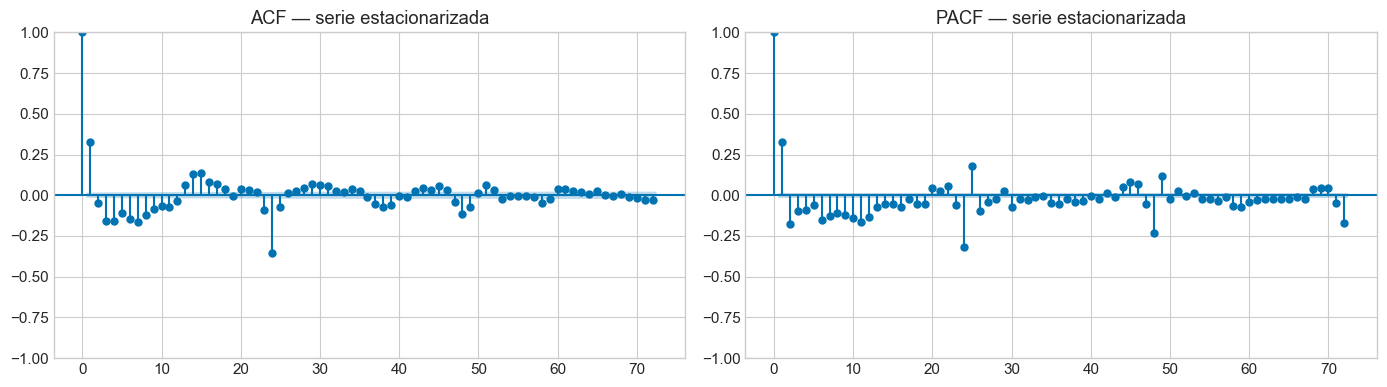

In [76]:
y_stat = y_train.diff(1).diff(SEASONAL_PERIOD).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_stat, lags=72, ax=axes[0])
axes[0].set_title("ACF — serie estacionarizada")
plot_pacf(y_stat, lags=72, ax=axes[1], method="ywm")
axes[1].set_title("PACF — serie estacionarizada")
plt.tight_layout()
plt.show()

### Conclusiones

- La serie estacionarizada $\tilde{y}_t = \Delta \Delta_{24}\, y_t$ **no es ruido blanco**. Es decir, persisten correlaciones significativas más allá del intervalo de confianza.
- **Lag 1** (ACF/PACF ≈ +0,33): dependencia de corto plazo. Se proponen componentes AR/MA regulares ($p$, $q$).
- **Lag 24** (ACF/PACF ≈ −0,35): estacionalidad diaria residual. Se proponen estacionales ($P$, $Q$) con $s = 24$.
- **Lags 48 y 72:** picos en múltiplos de $24$ confirman periodicidad diaria; la PACF en lag 25 sugiere posible interacción AR/MA estacional adicional.
- **Órdenes propuestos**
  - SARIMA $(1,1,1)(1,1,1)_{24}$, coherente con $d=1$, $D=1$ del ADF y con los correlogramas. Deben confirmarse con `auto_arima` y diagnóstico de residuos.

## 2.9 - Ruido blanco vs. caminata aleatoria

En esta sección se sintetizan los hallazgos de estacionaridad sin código adicional.

**Qué se concluye:** la serie de tráfico en **niveles** no se comporta como ruido blanco. Presenta memoria temporal, variabilidad local y una componente estacional determinística de periodo $24$ horas. El ADF puede rechazar $H_0$ incluso en niveles por el tamaño muestral ($n = 15879$), pero eso **no contradice** la necesidad de SARIMA: la evidencia principal está en la ACF/PACF (picos en $24, 48, 72$) y en la descomposición.

**Por qué importa:** los baselines de las secciones 2.4–2.6 modelan la estacionalidad de forma determinística (suavizado exponencial), pero no capturan toda la autocorrelación estocástica. Por eso es razonable pasar a **SARIMA**.

## 2.10 - Resumen

En esta sección se exportan los artefactos necesarios para el Notebook 3.

**Motivación:** desacoplar NB2 de NB3 permite re-ejecutar SARIMA sin re-ajustar baselines, y documenta decisiones de modelado (partición, órdenes propuestos, métricas de referencia).

**Archivos generados:**
- `dataset/processed/train_test_split.json` — fechas y tamaños de train/test.
- `dataset/results/metricas_modelos.csv` — MAE, RMSE, MAPE de baselines.
- `dataset/results/adf_results.csv` — estadístico y $p$-valor ADF.
- `dataset/results/sarima_orders_suggested.json` — órdenes $(p,d,q)(P,D,Q)_{24}$ propuestas.

In [77]:
sarima_orders_suggested = {
    "p": 1,
    "d": 1,
    "q": 1,
    "P": 1,
    "D": 1,
    "Q": 1,
    "s": SEASONAL_PERIOD,
    "nota": "Propuesta inicial basada en ACF/PACF; confirmar en NB3 con auto_arima",
}

metrics_path = RESULTS_DIR / "metricas_modelos.csv"
adf_path = RESULTS_DIR / "adf_results.csv"
orders_path = RESULTS_DIR / "sarima_orders_suggested.json"

metrics_baselines.to_csv(metrics_path, index=False)
adf_results.to_csv(adf_path, index=False)
with open(orders_path, "w", encoding="utf-8") as f:
    json.dump(sarima_orders_suggested, f, indent=2)

print(f"Guardado: {metrics_path}")
print(f"Guardado: {adf_path}")
print(f"Guardado: {orders_path}")

Guardado: C:\fiuba\CEIA-AST\TPs\TP-02\dataset\results\metricas_modelos.csv
Guardado: C:\fiuba\CEIA-AST\TPs\TP-02\dataset\results\adf_results.csv
Guardado: C:\fiuba\CEIA-AST\TPs\TP-02\dataset\results\sarima_orders_suggested.json
